In [11]:

# from macd_functions import *    # stock functions , not used for MFs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from mftool import Mftool
mf = Mftool()

from functools import reduce

### Part 1 is for General MF analysis. 
- It can be for all MFs or Portfolio MFs read from a file
- This doesnt have amount invested info
- Funds are catagorised like below:
    - small, mid, large, hybrid
    - flexi (multi, thematic ...)
    - hedge (multi asset, debt, overseas, gold, ... (having low or negative corralation with market))


#### Get MF codes and names from https://www.amfiindia.com/spages/NAVAll.txt



## Part 1 -- MF Analysis

In [9]:
period = '5y'    ## period for MF analysis .. longer the better ... '1y', '3y'

num_years = int(period[0])
count = 252 * num_years      # 252 for 1 year


## Reference for Risk Free return --> # kotak liquid fund
risk_free_mf = '0P0000XV6E.BO'   
risk_free_hist = yf.Ticker(risk_free_mf).history(period=period)
risk_free_hist['Week'] = risk_free_hist.index.strftime('%Y-%U')
risk_free_hist['Month'] = risk_free_hist.index.strftime('%Y-%m')
risk_free_hist['DATE'] = risk_free_hist.index.strftime('%Y-%m-%d')


## Reference for Market Benchmark return --> # Nifty50
market = '^NSEI'
market_hist = yf.Ticker(market).history(period=period)
market_hist['Week'] = market_hist.index.strftime('%Y-%U')
market_hist['Month'] = market_hist.index.strftime('%Y-%m')
market_hist['DATE'] = market_hist.index.strftime('%Y-%m-%d')


## Merging Risk free and Market returns datewise; --> to be used for MF ratio calculation
riskfree_market_df = pd.merge(risk_free_hist[['DATE', 'Close']], market_hist[['DATE', 'Close']],
                              suffixes=('_risk', '_market'),
                              on='DATE', how='inner')

ratio_names = ['beta', 'sharpe', 'alpha', 'info', 'up_capture', 'down_capture']

def get_ratios(hist_df, mf_cat):
    '''
    hist_df: daily returns of a stock/MF
    '''
    hist_df['Month'] = hist_df.index.strftime('%Y-%m')
    hist_df['Week'] = hist_df.index.strftime('%Y-%U')
    hist_df['DATE'] = hist_df.index.strftime('%Y-%m-%d')

    hist_riskfree_market_df = pd.merge(riskfree_market_df, hist_df[['DATE', 'Week', 'Close']], on='DATE', how='inner')

    ## Daily Returns in %
    returns_df = hist_riskfree_market_df.groupby('DATE')[['Close_risk','Close_market','Close']].mean().pct_change().dropna()   # Week, DATE
    returns_df.rename(columns={'Close_risk':'risk_free_return', 'Close_market':'market_return', 'Close':'weekly_return'}, inplace=True)

    
    ## ==== RATIOS ====
    # beta -- Covariance with Market/variance (self-covariance) of market
    covariance = np.cov(returns_df['weekly_return'], returns_df['market_return'])
    beta = covariance[0,1] / covariance[1,1]   


    # Alpha -- Return beyond market return
    expected_return = returns_df['risk_free_return'] + beta * (returns_df['market_return'] - returns_df['risk_free_return'])
    alpha = returns_df['weekly_return'] - expected_return
    
    
    # Sharpe
    excess_return = returns_df['weekly_return'] - returns_df['risk_free_return']
    num_period = returns_df.shape[0]
    # -- to be averaged on yearly basis. 52 if weekly and 252 (working days) if daily returns
    # -- scale factor for yearly ratio -- np.sqrt(252) or np.sqrt(52) 
    #       --> Stats stuff: Annual number is directly proportional to mean and variance (sqrt for std)
    sharpe_ratio = np.sqrt(252) * excess_return.mean() / excess_return.std()
    

    # Information Ratio -- Return over benchmark
    excess_return = returns_df['weekly_return'] - returns_df['market_return']
    info_ratio = np.sqrt(252) * excess_return.mean() / excess_return.std()
    
    
    ####################
    
    ## Capture Ratio
    mf_cat = mf_cat if mf_cat in benchmark_idx['id'] else 'large_3'
    
    hist_benchmark_df = pd.merge(benchmark_df[['date', mf_cat+'_Close']].rename(columns={'date':'DATE'}),
                                   hist_df, on='DATE', how='inner')
    # Month-on-Month Returns in %
    hist_benchmark_df.index = pd.to_datetime(hist_benchmark_df['DATE'], format="%Y-%m-%d")
    returns_df = hist_benchmark_df.resample('ME').last()[[mf_cat+'_Close','Close']].pct_change().dropna()
    
    # Upside and Downside
    up_fund_ret, up_benchmark_ret = returns_df[returns_df[mf_cat+'_Close'] >= 0][['Close', mf_cat+'_Close']].T.values
    down_fund_ret, down_benchmark_ret = returns_df[returns_df[mf_cat+'_Close'] < 0][['Close', mf_cat+'_Close']].T.values
    # Calculate the cumulative product (1 + return_1) * (1 + return_2) * ... - 1
    up_fund_ret_cumu = (1 + up_fund_ret).prod() - 1
    up_benchmark_ret_cumu = (1 + up_benchmark_ret).prod() - 1
    down_fund_ret_cumu = (1 + down_fund_ret).prod() - 1
    down_benchmark_ret_cumu = (1 + down_benchmark_ret).prod() - 1
    #
    upside_capture_ratio = (up_fund_ret_cumu / up_benchmark_ret_cumu) * 100
    downside_capture_ratio = (down_fund_ret_cumu / down_benchmark_ret_cumu) * 100
    overall_capture_ratio = upside_capture_ratio / downside_capture_ratio



    return {'sharpe':round(sharpe_ratio,2),
            'beta':round(beta,2),
            'alpha':round(alpha.mean()*100,2),
            'info':round(info_ratio,2),
            'up_capture':upside_capture_ratio,
            'down_capture':downside_capture_ratio
            }


###===================



## Get rolling ratios == to study the evolution over time : More consistent the better
roll_lengths = [18]   # [12,15,18,24] months

def rolling_results(hist_df, mf_cat):
    hist_df['Month'] = hist_df.index.strftime('%Y-%m')
    months = hist_df['Month'].unique()
    roll_result_df = pd.DataFrame(columns=['start_month','roll_length']+ratio_names)
    roll_elas = {}
    for roll_len in roll_lengths:
        roll_sets = [months[i:i+roll_len] for i in range(len(months)-roll_len+1)]
        for roll_months in roll_sets:
            roll_df = hist_df[hist_df['Month'].isin(roll_months)].copy()
            vals = get_ratios(roll_df, mf_cat)

            roll_result_df.loc[len(roll_result_df)] = [roll_df['Month'].iloc[0], roll_len] + list(vals.values())

    return roll_result_df.to_dict(orient='list')


###====================

# Benchmark Ref for Info ratio
benchmark_idx = {'name':['large', 'mid', 'small', 'flexi'],    # nippon, MO ,nippon, MO
                 'id':['large_3', 'mid_2', 'small_1', 'flexi_4'],
                 'code':[118741, 147622, 148519, 147625],
                 }
# 'balanced':'CRISIL Hybrid 50+50 - Moderate Index',
# 'debt':'CRISIL Hybrid 85+15 - Conservative Index'

benchmark_df = []
for idx, code in zip(benchmark_idx['id'], benchmark_idx['code']):
    df = mf.get_scheme_historical_nav(code,as_Dataframe=True).iloc[::-1].iloc[-count:].astype(float)
    df.rename(columns={'nav':idx+'_Close'}, inplace=True)
    df.index = pd.to_datetime(df.index, format="%d-%m-%Y").strftime('%Y-%m-%d')
    benchmark_df.append(df.reset_index()[['date', idx+'_Close']])
benchmark_df = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), benchmark_df)


###=================


## List of all MFs available in the market
names = ['small_1', 'mid_2', 'large_3', 'flexi_4']
idx = 1    # Index of category to be studied
mf_dict = mf.get_available_schemes(names[idx].split('_')[0])

## Extract single fund for each house-category from the entire list
mf_dict_ref = {k:v for k,v in mf_dict.items() if all(w in v.lower() for w in ['direct','growth'])}
if names[idx]=='mid_2': mf_dict_ref = {k:v for k,v in mf_dict_ref.items() if 'large' not in v.lower() and 'small' not in v.lower()}
if names[idx]=='large_3': mf_dict_ref = {k:v for k,v in mf_dict_ref.items() if 'mid' not in v.lower()}


mf_all = {'name':list(mf_dict_ref.values()),
          'id':names[idx],
          'code':list(mf_dict_ref.keys()),
          }


In [12]:

# Flag to analyse All MFs or Portfolio MFs
all_MFs = False 


## Read portfolio MFs stored in csv
mf_df = pd.read_csv('../mf_ga_amfi.csv')
    
if not all_MFs:
    # Appending benchmark for each category for comparison
    mf_df = pd.concat([mf_df, pd.DataFrame.from_dict(benchmark_idx)])
else:
    # my_codes = mf_df['code'].to_list()
    my_mf_names = mf_df[mf_df['id']==names[idx]]['name'].apply(lambda x: ' '.join(x.split(' ')[:2])).str.lower().tolist()
    ## All MFs
    mf_df = pd.DataFrame.from_dict(mf_all)
    ## Get MFs which are in Portfolio
    mf_df['short_name'] = mf_df['name'].apply(lambda x: ' '.join(x.split(' ')[:2])).str.lower()
    my_codes = mf_df[mf_df['short_name'].isin(my_mf_names)]['code'].to_list()
    mf_df['portfolio'] = mf_df['code'].apply(lambda x: 1 if x in my_codes else 0)
    my_mf_names = mf_df[mf_df['portfolio'] == 1]['name'].values


mf_fall = {}
latest = []


ratios = {k: [] for k in ratio_names}
rolling_ratios = {k: [] for k in ratio_names}

mf_names = mf_df['name'].values
returns_report = {}

##== Iterate for each MF separately 
for idx, row in mf_df.iterrows():
    
    df = mf.get_scheme_historical_nav(row['code'],as_Dataframe=True)
    df.rename(columns={'nav':'Close'}, inplace=True)
    df = df.iloc[::-1]
    df['Close'] = df['Close'].astype(float)
    df = df.iloc[-count:]    # Consider from last given years
    df.index = pd.to_datetime(df.index, format="%d-%m-%Y")

    # Latest NAV
    latest.append(df.iloc[0]['Close'])

    ## After 26th Sept 2024 -- High before started falling
    if df[df.index <= '2024-09-26'].shape[0]:
        mf_fall[row['name']] = df['Close'].loc[df[df.index == '2024-09-26'].index[0]:].values
    else:
        mf_fall[row['name']] = df['Close'].values


    # Ratios
    vals = get_ratios(df.copy(), row['id'])
    for k in ratios:
        ratios[k].append(vals[k])

    # Rolling ratios
    roll_vals = rolling_results(df.copy(), row['id'])
    for k in rolling_ratios:
        rolling_ratios[k].append(roll_vals[k])

    # Report returns
    if df.shape[0] == count:
        cagr = (df['Close'].iloc[-1] / df['Close'].iloc[0]) ** (1 / num_years) - 1
        returns_report[row['name']] = cagr * 100
    else:
        returns_report[row['name']] = np.nan


## Summariese into a DF
for k in ratios:
    mf_df[k] = ratios[k]
mf_df['nav'] = latest

for k in rolling_ratios:
    mf_df[f'rolling_{k}'] = rolling_ratios[k]

mf_df['returns_%'] = mf_df['name'].map(returns_report)

# mf_df.sort_values(['id', 'info'], ascending=False)
mf_df.round(2)

,name,id,code,beta,sharpe,alpha,info,up_capture,down_capture,nav,rolling_beta,rolling_sharpe,rolling_alpha,rolling_info,rolling_up_capture,rolling_down_capture,returns_%
0,HDFC Balanced Advantage Fund - Direct Plan - G...,hybrid_5,118968,0.63,1.20,0.03,0.89,86.63,55.18,260.97,"[1.79, 1.53, 1.61, 1.33, 1.16, 0.94, 0.84, 0.5...","[0.58, 0.59, 0.59, 0.6, 0.6, 0.6, 0.6, 0.6, 0....","[0.05, 0.05, 0.04, 0.04, 0.04, 0.03, 0.04, 0.0...","[0.75, 0.84, 0.76, 0.58, 0.73, 0.77, 1.41, 1.3...","[84.01019921498157, 84.01019921498157, 77.3190...","[26.727481083676324, 30.778521485622022, 30.77...",16.65
1,HDFC Flexi Cap Fund - Direct Plan - Growth Option,flexi_4,118955,0.87,1.16,0.04,1.86,104.84,72.46,898.33,"[1.51, 1.3, 1.39, 1.16, 0.98, 0.8, 0.62, 0.39,...","[0.9, 0.9, 0.9, 0.91, 0.91, 0.91, 0.91, 0.91, ...","[0.05, 0.05, 0.05, 0.04, 0.04, 0.04, 0.05, 0.0...","[1.59, 1.64, 1.63, 1.35, 1.44, 1.41, 2.08, 1.8...","[104.96210930939552, 106.47297813017983, 105.6...","[57.029028085506916, 61.47359851645693, 61.473...",19.53
2,HDFC Hybrid Debt Fund - Direct Plan - Growth O...,hybrid_5,119118,0.24,0.96,0.01,-0.21,30.88,20.58,54.70,"[1.01, 1.41, 1.6, 1.3, 1.32, 1.11, 0.8, 0.49, ...","[0.22, 0.22, 0.22, 0.22, 0.23, 0.23, 0.23, 0.2...","[0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.0...","[-0.12, -0.46, -0.53, -0.34, -0.47, -0.41, -0....","[39.358111856146124, 35.93400061644725, 36.721...","[13.381246752382795, 13.381246752382795, 13.38...",10.16
3,HDFC Index FundNIFTY 50 Plan - Direct Plan,large_3,119063,1.00,0.48,0.00,3.46,99.91,100.12,141.68,"[0.9, 0.67, 0.78, 0.68, 0.47, 0.3, -0.1, -0.21...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.01, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[4.15, 3.97, 4.0, 3.99, 3.58, 3.21, 3.28, 3.2,...","[99.89137953027961, 99.89137953027961, 99.8544...","[100.03411116050766, 99.98439040686905, 99.984...",10.81
4,HDFC NIFTY Next50 Index Fund Direct Growth,large_3,149288,1.08,0.38,0.02,0.51,168.41,123.00,9.99,"[-0.47, -0.18, -0.1, 0.09, 0.17, -0.04, -0.16,...","[0.98, 0.97, 0.97, 0.96, 0.94, 0.95, 0.97, 0.9...","[-0.02, -0.02, -0.01, -0.01, -0.01, -0.0, -0.0...","[-0.58, -0.45, -0.34, -0.19, -0.26, -0.12, -0....","[96.92826993251475, 112.90389419367463, 113.17...","[138.64032871196275, 138.64032871196275, 130.2...",NaN
5,ICICI Prudential Balanced Advantage Fund - Dir...,hybrid_5,120377,0.41,1.05,0.02,0.07,45.69,30.95,48.83,"[1.59, 1.39, 1.41, 1.17, 0.96, 0.7, 0.41, 0.22...","[0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.3...","[0.02, 0.02, 0.02, 0.01, 0.01, 0.01, 0.01, 0.0...","[-0.37, -0.14, -0.3, -0.28, -0.11, 0.01, 0.45,...","[43.31454537247452, 43.31454537247452, 42.7620...","[9.882956826400825, 14.367807262211851, 14.367...",12.08
6,ICICI Prudential Focused Equity Fund - Direct ...,flexi_4,120722,0.91,1.05,0.04,1.73,121.40,88.57,44.68,"[1.26, 1.04, 1.11, 0.94, 0.69, 0.45, 0.12, -0....","[0.89, 0.89, 0.9, 0.9, 0.9, 0.89, 0.88, 0.88, ...","[0.03, 0.03, 0.03, 0.02, 0.02, 0.01, 0.02, 0.0...","[1.12, 1.24, 1.1, 0.91, 0.79, 0.61, 0.97, 0.84...","[107.14953554959581, 106.98825803335244, 109.8...","[90.93085754950916, 89.50858523461423, 89.5085...",19.17
7,ICICI Prudential Multi-Asset Fund - Direct Pla...,hedge_6,120334,0.54,1.59,0.04,1.04,79.66,28.50,360.18,"[2.01, 1.8, 1.81, 1.65, 1.56, 1.33, 1.05, 0.75...","[0.54, 0.54, 0.54, 0.54, 0.54, 0.54, 0.53, 0.5...","[0.05, 0.05, 0.05, 0.05, 0.05, 0.04, 0.05, 0.0...","[0.81, 0.98, 0.79, 0.77, 1.02, 1.03, 1.4, 1.28...","[83.02615715069214, 83.02615715069214, 78.6334...","[0.3345749328106946, 15.95736604387365, 15.957...",20.07
8,ICICI Prudential Nifty50 Value20 Index Fund - ...,large_3,152365,0.92,-0.19,-0.01,-0.36,80.29,96.80,9.99,"[-0.15, -0.28, -0.22, -0.09, -0.12, -0.29, -0....","[0.96, 0.96, 0.96, 0.96, 0.97, 0.97, 0.96, 0.9...","[-0.02, -0.02, -0.01, -0.02, -0.02, -0.01, -0....","[-0.96, -0.78, -0.67, -0.83, -0.82, -0.63, -0....","[79.02842573432822, 86.05124686790333, 80.9459...","[117.3352747307507, 110.3013360002903, 110.301...",NaN
9,ICICI Prudential Smallcap

### Result Analysis

### 1. Percentage Change compared to All Time High
- MFs having returns >0 shows good recovery compared to Market and other peers
- Mfs are color coded in Plot for segregation
- 'mid', 'small', 'large', 'flexi' --> show market benchmark returns compared to ATH

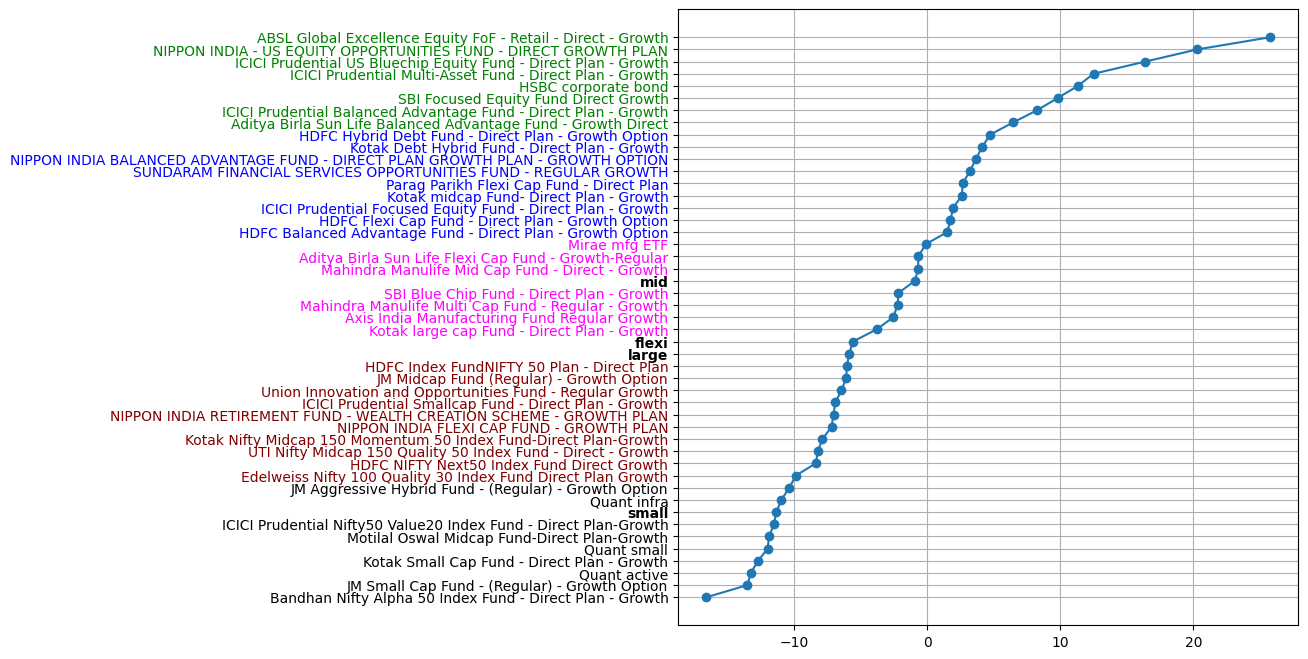

In [13]:
## Percentage variation

fig = plt.figure(figsize=(8,8))

change_list, mf_names = [], []
for name, vals in mf_fall.items():
    change = (vals[-1] - vals[0])/vals[0]
    change_list.append(round(change*100, 2))
    mf_names.append(name)

mf_names1, change_list = zip(*sorted(zip(mf_names, change_list), key=lambda x: x[1]))

plt.plot(change_list, mf_names1, marker='o')

ax = plt.gca()
for i, label in enumerate(ax.get_yticklabels()):
    if change_list[i] > 5: label.set_color('green')
    elif change_list[i] < 5 and change_list[i] > 0: label.set_color('blue')
    elif change_list[i] < 0 and change_list[i] > -5: label.set_color('magenta')
    elif change_list[i] < -5 and change_list[i] > -10: label.set_color('maroon')
    if label.get_text() in benchmark_idx['name']:
        label.set_fontweight('bold')
        label.set_color('black')
    # Highlight my MFs
    if all_MFs:
        if label.get_text() in my_mf_names: label.set_fontweight('bold')


plt.grid(True, which='both')
plt.show()

### 2.1 Absolute returns for all_mfs
- Useful to check missed out value compared to other funds

In [ ]:
if all_MFs:
    beginning_value = 1000000
    mf_df['abs_return'] = beginning_value * (1 + mf_df['returns_%'])**num_years

    df_plot = mf_df[['name', 'id', 'code', 'returns_%', 'abs_return']].sort_values('returns_%', ascending=True)
    plt.plot(df_plot['returns_%'], df_plot['name'], marker='o')
    plt.xlabel(f'Absolute Returns of {beginning_value} over {num_years} years')
    plt.grid()

    ax = plt.gca()
    for i, label in enumerate(ax.get_yticklabels()):
        # Highlight my MFs
        if label.get_text() in my_mf_names: label.set_fontweight('bold')


### 2. Category-wise Percentage Variation from ATH for detailed analysis
- To analyse performance/behaviour of MF over last year

In [ ]:

for cat, df in mf_df.groupby('id'):
    fig = plt.figure(figsize=(10,8))

    for idx, row in df.iterrows():
        vals = mf_fall[row['name']]
        pc_var = (vals - vals[0])*100/vals[0]
        plt.plot(pc_var, label=row['name'][:25])
    plt.xticks(rotation=90)
    plt.grid(True, which='both')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()




### 3. Analysis of Ratios -- Important

1. Sharpe Ratio: Returns over risk free, weighted by its variance. Higher value is better returns comapred to Risk taken
    - Neagtive sharpe ratio: Underperformance of asset in a given period.
    
2. Beta: Relative volatality with Market.
    - Low value means less fluctuations compared to market and Good for short term durations
    
3. Alpha: Extra return over Market and Risk free return, weighted by Beta
4. Info: it measures ability to generate risk-adjusted excess returns above a benchmark, quantifying a fund manager's skill and consistency in outperforming the market.
    - Its fund's return over benchmark return, divided by SD of this excess return.
    - Higher value shows that fund manager is consistently generating higher returns than the benchmark with less risk.
    - Sharpe is with Risk free and Info with benchmark
    
    - (There is intentional bug in code. Info Ratio is calculated with Nifty50 for general comparision. Ideally its calculated with category benchmark for that fund (eg. mid, small, flexi)
    
5. Capture Ratio
    - Upside Ratio > 100%: The fund outperforms the benchmark during rising markets.
    - Downside Ratio < 100%: The fund loses less than the benchmark during falling markets, indicating better risk mitigation.
    - Overall Ratio > 1: The fund has provided superior risk-adjusted returns overall compared to its benchmark. 

In [ ]:

for ratio in ratios.keys():
    fig = plt.figure(figsize=(6,10))
    for cat, df in mf_df.groupby('id'):
        df = df.sort_values(by=ratio)
        plt.barh(df['name'], df[ratio], label=cat)
        plt.barh('----'+cat+'----', 0, label=None)
    plt.title(ratio)
    plt.xticks(rotation=90)
    plt.grid(True, axis='x')
    plt.legend()

    ax = plt.gca()
    for i, label in enumerate(ax.get_yticklabels()):
        if label.get_text() in benchmark_idx['name']:
            label.set_fontweight('bold')
            label.set_color('maroon')

        # Highlight my MFs
        if all_MFs:
            if label.get_text() in my_mf_names: label.set_fontweight('bold')

    plt.show()



### 3.1 Returns vs Ratios for MFs

In [ ]:
## 3.1 Returns vs Ratios for MFs
#     - Plot returns (ascending) vs each ratio (beta, alpha, sharpe, info)

import matplotlib.patches as mpatches

rainbow_colors = ['Red', 'Orange', 'Yellow', 'Green', 'Blue', 'Indigo', 'Violet']
col_map = {cat:color for cat, color in zip(mf_df['id'].unique(), rainbow_colors)}


for ratio in ratios.keys():
    # prepare dataframe for plotting
    df_plot = mf_df[['id','name', 'returns_%', ratio]].copy()
    df_plot = df_plot.dropna(subset=['returns_%', ratio]).sort_values(['id','returns_%'], ascending=[True,True]).reset_index(drop=True)
    colors = df_plot['id'].map(col_map).to_list()

    names = df_plot['name'].tolist()
    y = np.arange(len(names))

    fig, ax = plt.subplots(figsize=(10, max(6, len(names) * 0.18)))
    ax.barh(y, df_plot['returns_%'], color=colors, edgecolor='k')
    ax.set_yticks(y)
    ax.set_yticklabels(names)
    ax.set_xlabel('Returns (%)')
    ax.set_title(f'MF Returns (%) (asc) and {ratio.capitalize()}')

    # secondary axis for the ratio
    ax2 = ax.twiny()
    ax2.plot(df_plot[ratio].values, y, 'o', color='crimson')
    ax2.set_xlabel(ratio.capitalize())

    # annotate ratio values and bold portfolio funds
    my_names_set = set(list(my_mf_names)) if 'my_mf_names' in globals() else set()
    for i, (val, lab) in enumerate(zip(df_plot[ratio].values, ax.get_yticklabels())):
        try:
            ax2.annotate(f'{val:.2f}', xy=(val, i), xytext=(6, 0), textcoords='offset points',
                         va='center', fontsize=7, color='crimson')
        except Exception:
            # fallback for non-scalar values
            ax2.annotate(f'{float(np.asarray(val).flat[0]):.2f}', xy=(float(np.asarray(val).flat[0]), i),
                         xytext=(6, 0), textcoords='offset points', va='center', fontsize=7, color='crimson')

        if lab.get_text() in my_names_set:
            lab.set_fontweight('bold')

    ax.grid(True, axis='x', which='major', linestyle='--', alpha=0.5)

    # 4. Create manual patches for the custom legend
    patches = [mpatches.Patch(color=c, label=l) for l,c in col_map.items()]
    ax.legend(handles=patches, loc='lower right')
    
    # Bold benchmarks
    for i, label in enumerate(ax.get_yticklabels()):
        if label.get_text() in benchmark_idx['name']:
            label.set_fontweight('bold')
            label.set_color('black')


    plt.tight_layout()
    plt.show()

### 4. Rolling ratio variations

In [ ]:
for cat, df in mf_df.groupby('id'):
    fig = plt.figure(figsize=(18,4))
    fig.suptitle(cat, fontsize=20)
    
    for i, ratio in enumerate(ratio_names):

        ax = fig.add_subplot(1,len(ratio_names),i+1)
        for index, row in df.iterrows():
            plt.plot(row[f'rolling_{ratio}'], label='_'.join(row['name'].split(' ')[:1]))
        plt.xlabel(ratio)
        plt.legend()



    plt.show()

### 5. Plotting all ratios together for each fund and sorted
- Can be useful for comparison within each other

In [ ]:
for cat, df in mf_df.groupby('id'):
    fig = plt.figure(figsize=(12,4))
    fig.suptitle(cat, fontsize=20)
    ax = fig.add_subplot(1,2,1)
    df = df[['name','alpha', 'beta', 'sharpe']].copy()
    df['beta'] = 1 - (df['beta'] - df['beta'].min()) / (df['beta'].max() - df['beta'].min())
    df.sort_values(by='sharpe').set_index('name').plot.bar(ax=ax)

    ax = fig.add_subplot(1,2,2)
    plt.scatter(df['alpha'], df['sharpe'], s=df['beta']*100)
    for _, row in df.iterrows():
        plt.annotate(row['name'].split(' ')[0], xy=(row['alpha'],row['sharpe']), fontsize=6, rotation=35)
    plt.xlabel('Alpha')
    plt.ylabel('Sharpe')
    plt.grid(True, which='both')
    plt.show()


In [18]:
import sys
import os
# sys.path.insert(0, os.path.dirname(__file__))

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from mftool import Mftool
from functools import reduce


# ── Config ────────────────────────────────────────────────────────────────────
PERIOD       = '5y'
NUM_YEARS    = int(PERIOD[0])
COUNT        = 252 * NUM_YEARS
ALL_MFs      = False
DATA_PATH = "mf-analysis/data/mf_ga_amfi.csv"
PORTFOLIO_PATH = "mf-analysis/data/portfolio.csv"

RISK_FREE_MF = '0P0000XV6E.BO'
MARKET       = '^NSEI'

RATIO_NAMES  = ['beta', 'sharpe', 'alpha', 'info', 'up_capture', 'down_capture']

BENCHMARK_IDX = {
    'name': ['large', 'mid', 'small', 'flexi'],
    'id':   ['large_3', 'mid_2', 'small_1', 'flexi_4'],
    'code': [118741, 147622, 148519, 147625],
}

mf = Mftool()


# ── Reference Data ────────────────────────────────────────────────────────────
def load_reference_data():
    print("Fetching risk-free and market data...")
    risk_free_hist = yf.Ticker(RISK_FREE_MF).history(period=PERIOD)
    market_hist    = yf.Ticker(MARKET).history(period=PERIOD)

    risk_free_hist['DATE'] = risk_free_hist.index.strftime('%Y-%m-%d')
    market_hist['DATE']    = market_hist.index.strftime('%Y-%m-%d')

    riskfree_market_df = pd.merge(
        risk_free_hist[['DATE', 'Close']],
        market_hist[['DATE', 'Close']],
        suffixes=('_risk', '_market'),
        on='DATE', how='inner'
    )
    return riskfree_market_df


def load_benchmark_data():
    print("Fetching benchmark data...")
    benchmark_df = []
    for idx, code in zip(BENCHMARK_IDX['id'], BENCHMARK_IDX['code']):
        df = mf.get_scheme_historical_nav(code, as_Dataframe=True) \
               .iloc[::-1].iloc[-COUNT:].astype(float)
        df.rename(columns={'nav': idx + '_Close'}, inplace=True)
        df.index = pd.to_datetime(df.index, format="%d-%m-%Y").strftime('%Y-%m-%d')
        benchmark_df.append(df.reset_index()[['date', idx + '_Close']])
    return reduce(
        lambda left, right: pd.merge(left, right, on='date', how='outer'),
        benchmark_df
    )


# ── Ratios ────────────────────────────────────────────────────────────────────
def get_ratios(hist_df, mf_cat, riskfree_market_df, benchmark_df):
    hist_df = hist_df.copy()
    hist_df['DATE'] = hist_df.index.strftime('%Y-%m-%d')

    merged = pd.merge(riskfree_market_df, hist_df[['DATE', 'Close']], on='DATE', how='inner')
    returns_df = merged.groupby('DATE')[['Close_risk', 'Close_market', 'Close']] \
                       .mean().pct_change().dropna()
    returns_df.rename(columns={
        'Close_risk':   'risk_free_return',
        'Close_market': 'market_return',
        'Close':        'weekly_return'
    }, inplace=True)

    # Beta
    cov  = np.cov(returns_df['weekly_return'], returns_df['market_return'])
    beta = cov[0, 1] / cov[1, 1]

    # Alpha
    expected_return = (returns_df['risk_free_return']
                       + beta * (returns_df['market_return'] - returns_df['risk_free_return']))
    alpha = returns_df['weekly_return'] - expected_return

    # Sharpe
    excess_rf   = returns_df['weekly_return'] - returns_df['risk_free_return']
    sharpe      = np.sqrt(252) * excess_rf.mean() / excess_rf.std()

    # Info
    excess_mkt  = returns_df['weekly_return'] - returns_df['market_return']
    info        = np.sqrt(252) * excess_mkt.mean() / excess_mkt.std()

    # Capture Ratios
    cat = mf_cat if mf_cat in BENCHMARK_IDX['id'] else 'large_3'
    bench_col = cat + '_Close'
    hist_bench = pd.merge(
        benchmark_df[['date', bench_col]].rename(columns={'date': 'DATE'}),
        hist_df, on='DATE', how='inner'
    )
    # Month-on-Month Returns in %
    hist_bench.index = pd.to_datetime(hist_bench['DATE'], format="%Y-%m-%d")
    monthly = hist_bench.resample('ME').last()[[bench_col, 'Close']].pct_change().dropna()
    # Upside and Downside
    up   = monthly[monthly[bench_col] >= 0]
    down = monthly[monthly[bench_col] <  0]
    # Calculate the cumulative product (1 + return_1) * (1 + return_2) * ... - 1
    up_fund_cumu    = (1 + up['Close']).prod()   - 1
    up_bench_cumu   = (1 + up[bench_col]).prod() - 1
    down_fund_cumu  = (1 + down['Close']).prod()   - 1
    down_bench_cumu = (1 + down[bench_col]).prod() - 1

    up_capture   = (up_fund_cumu   / up_bench_cumu)   * 100 if up_bench_cumu   != 0 else np.nan
    down_capture = (down_fund_cumu / down_bench_cumu) * 100 if down_bench_cumu != 0 else np.nan

    return {
        'sharpe':       round(sharpe, 2),
        'beta':         round(beta, 2),
        'alpha':        round(alpha.mean() * 100, 2),
        'info':         round(info, 2),
        'up_capture':   round(up_capture, 2),
        'down_capture': round(down_capture, 2),
    }


# ── Rolling Ratios ────────────────────────────────────────────────────────────
ROLL_LENGTHS = [18]

def rolling_results(hist_df, mf_cat, riskfree_market_df, benchmark_df):
    hist_df = hist_df.copy()
    hist_df['Month'] = hist_df.index.strftime('%Y-%m')
    months = hist_df['Month'].unique()

    roll_result_df = pd.DataFrame(columns=['start_month', 'roll_length'] + RATIO_NAMES)
    for roll_len in ROLL_LENGTHS:
        for i in range(len(months) - roll_len + 1):
            roll_months = months[i:i + roll_len]
            roll_df     = hist_df[hist_df['Month'].isin(roll_months)].copy()
            vals        = get_ratios(roll_df, mf_cat, riskfree_market_df, benchmark_df)
            roll_result_df.loc[len(roll_result_df)] = (
                [roll_df['Month'].iloc[0], roll_len] + list(vals.values())
            )
    return roll_result_df.to_dict(orient='list')


# ── Portfolio / All MFs ───────────────────────────────────────────────────────
def load_mf_df(csv_path: str = None):
    path = csv_path or DATA_PATH
    mf_df = pd.read_csv(path)

    if not ALL_MFs:
        mf_df = pd.concat([mf_df, pd.DataFrame.from_dict(BENCHMARK_IDX)], ignore_index=True)
        return mf_df, None

    # All MFs mode
    names = ['small_1', 'mid_2', 'large_3', 'flexi_4']
    cat_idx = 1
    mf_dict = mf.get_available_schemes(names[cat_idx].split('_')[0])
    mf_dict_ref = {k: v for k, v in mf_dict.items()
                   if all(w in v.lower() for w in ['direct', 'growth'])}
    if names[cat_idx] == 'mid_2':
        mf_dict_ref = {k: v for k, v in mf_dict_ref.items()
                       if 'large' not in v.lower() and 'small' not in v.lower()}
    if names[cat_idx] == 'large_3':
        mf_dict_ref = {k: v for k, v in mf_dict_ref.items()
                       if 'mid' not in v.lower()}

    my_mf_names = (mf_df[mf_df['id'] == names[cat_idx]]['name']
                   .apply(lambda x: ' '.join(x.split(' ')[:2])).str.lower().tolist())

    all_df = pd.DataFrame({'name': list(mf_dict_ref.values()),
                           'id':   names[cat_idx],
                           'code': list(mf_dict_ref.keys())})
    all_df['short_name'] = all_df['name'].apply(lambda x: ' '.join(x.split(' ')[:2])).str.lower()
    my_codes = all_df[all_df['short_name'].isin(my_mf_names)]['code'].tolist()
    all_df['portfolio'] = all_df['code'].apply(lambda x: 1 if x in my_codes else 0)
    return all_df, all_df[all_df['portfolio'] == 1]['name'].values


# ── Main Analysis ─────────────────────────────────────────────────────────────
def run_analysis(csv_path: str = None):
    riskfree_market_df = load_reference_data()
    benchmark_df       = load_benchmark_data()
    mf_df, my_mf_names = load_mf_df(csv_path)   # ← pass path here

    mf_fall       = {}
    latest        = []
    ratios        = {k: [] for k in RATIO_NAMES}
    rolling_r     = {k: [] for k in RATIO_NAMES}
    returns_report = {}

    total = len(mf_df)
    for i, (idx, row) in enumerate(mf_df.iterrows(), 1):
        print(f"[{i}/{total}] Analysing: {row['name']}")
        try:
            df = mf.get_scheme_historical_nav(row['code'], as_Dataframe=True)
            df.rename(columns={'nav': 'Close'}, inplace=True)
            df = df.iloc[::-1].iloc[-COUNT:]
            df['Close'] = df['Close'].astype(float)
            df.index    = pd.to_datetime(df.index, format="%d-%m-%Y")

            latest.append(df['Close'].iloc[-1])

            cutoff = '2024-09-26'
            mf_fall[row['name']] = (
                df['Close'].loc[df[df.index <= cutoff].index[0]:].values
                if df[df.index <= cutoff].shape[0] else df['Close'].values
            )

            vals = get_ratios(df.copy(), row['id'], riskfree_market_df, benchmark_df)
            for k in RATIO_NAMES:
                ratios[k].append(vals[k])

            roll_vals = rolling_results(df.copy(), row['id'], riskfree_market_df, benchmark_df)
            for k in RATIO_NAMES:
                rolling_r[k].append(roll_vals[k])

            if df.shape[0] == COUNT:
                cagr = (df['Close'].iloc[-1] / df['Close'].iloc[0]) ** (1 / NUM_YEARS) - 1
                returns_report[row['name']] = round(cagr * 100, 2)
            else:
                returns_report[row['name']] = np.nan

        except Exception as e:
            print(f"  ⚠ Skipped {row['name']}: {e}")
            latest.append(np.nan)
            mf_fall[row['name']] = np.array([])
            for k in RATIO_NAMES:
                ratios[k].append(np.nan)
                rolling_r[k].append([])
            returns_report[row['name']] = np.nan

    for k in RATIO_NAMES:
        mf_df[k] = ratios[k]
    mf_df['nav']      = latest
    mf_df['returns_%'] = mf_df['name'].map(returns_report)
    for k in RATIO_NAMES:
        mf_df[f'rolling_{k}'] = rolling_r[k]

    return mf_df, mf_fall, my_mf_names


# ── Plots ─────────────────────────────────────────────────────────────────────
def plot_ath_change(mf_fall, my_mf_names):
    change_list, names = [], []
    for name, vals in mf_fall.items():
        if len(vals) < 2:
            continue
        change_list.append(round((vals[-1] - vals[0]) / vals[0] * 100, 2))
        names.append(name)

    names, change_list = zip(*sorted(zip(names, change_list), key=lambda x: x[1]))

    plt.figure(figsize=(8, 8))
    plt.plot(change_list, names, marker='o')
    ax = plt.gca()
    for i, label in enumerate(ax.get_yticklabels()):
        v = change_list[i]
        if   v > 5:            label.set_color('green')
        elif 0 < v <= 5:       label.set_color('blue')
        elif -5 < v <= 0:      label.set_color('magenta')
        elif -10 < v <= -5:    label.set_color('maroon')
        if label.get_text() in BENCHMARK_IDX['name']:
            label.set_fontweight('bold'); label.set_color('black')
        if ALL_MFs and my_mf_names is not None and label.get_text() in my_mf_names:
            label.set_fontweight('bold')
    plt.grid(True)
    plt.title('% Change from ATH (26-Sep-2024)')
    plt.tight_layout()
    plt.savefig('output/ath_change.png', dpi=150)
    plt.show()


def plot_ratios(mf_df, my_mf_names):
    for ratio in RATIO_NAMES:
        plt.figure(figsize=(6, 10))
        for cat, df in mf_df.groupby('id'):
            df = df.sort_values(by=ratio)
            plt.barh(df['name'], df[ratio], label=cat)
            plt.barh('----' + cat + '----', 0)
        plt.title(ratio)
        plt.grid(True, axis='x')
        plt.legend()
        ax = plt.gca()
        for label in ax.get_yticklabels():
            if label.get_text() in BENCHMARK_IDX['name']:
                label.set_fontweight('bold'); label.set_color('maroon')
            if ALL_MFs and my_mf_names is not None and label.get_text() in my_mf_names:
                label.set_fontweight('bold')
        plt.tight_layout()
        plt.savefig(f'output/ratio_{ratio}.png', dpi=150)
        plt.show()


def plot_rolling_ratios(mf_df):
    for cat, df in mf_df.groupby('id'):
        fig, axes = plt.subplots(1, len(RATIO_NAMES), figsize=(18, 4))
        fig.suptitle(cat, fontsize=16)
        for i, ratio in enumerate(RATIO_NAMES):
            for _, row in df.iterrows():
                axes[i].plot(row[f'rolling_{ratio}'],
                             label=row['name'].split(' ')[0])
            axes[i].set_title(ratio)
            axes[i].legend(fontsize=6)
        plt.tight_layout()
        plt.savefig(f'output/rolling_{cat}.png', dpi=150)
        plt.show()





In [19]:
# os.makedirs(os.path.join(os.path.dirname(__file__), '../output'), exist_ok=True)

mf_df, mf_fall, my_mf_names = run_analysis()

print("\n=== Summary ===")
print(mf_df[['name', 'id', 'returns_%'] + RATIO_NAMES].round(2).to_string())

# Save results
out_csv = os.path.join(os.path.dirname(__file__), '../output/mf_results.csv')
mf_df[['name', 'id', 'code', 'nav', 'returns_%'] + RATIO_NAMES].to_csv(out_csv, index=False)
print(f"\nResults saved to {out_csv}")

plot_ath_change(mf_fall, my_mf_names)
plot_ratios(mf_df, my_mf_names)
plot_rolling_ratios(mf_df)

Fetching risk-free and market data...
Fetching benchmark data...
[1/47] Analysing: HDFC Balanced Advantage Fund - Direct Plan - Growth Option
[2/47] Analysing: HDFC Flexi Cap Fund - Direct Plan - Growth Option
[3/47] Analysing: HDFC Hybrid Debt Fund - Direct Plan - Growth Option
[4/47] Analysing: HDFC Index FundNIFTY 50 Plan - Direct Plan
[5/47] Analysing: HDFC NIFTY Next50 Index Fund Direct Growth
[6/47] Analysing: ICICI Prudential Balanced Advantage Fund - Direct Plan - Growth
[7/47] Analysing: ICICI Prudential Focused Equity Fund - Direct Plan - Growth
[8/47] Analysing: ICICI Prudential Multi-Asset Fund - Direct Plan - Growth
[9/47] Analysing: ICICI Prudential Nifty50 Value20 Index Fund - Direct Plan-Growth
[10/47] Analysing: ICICI Prudential Smallcap Fund - Direct Plan - Growth
[11/47] Analysing: ICICI Prudential US Bluechip Equity Fund - Direct Plan - Growth
[12/47] Analysing: Motilal Oswal Midcap Fund-Direct Plan-Growth
[13/47] Analysing: NIPPON INDIA - US EQUITY OPPORTUNITIES FU

NameError: name '__file__' is not defined

In [22]:
df = mf.get_scheme_historical_nav('118955', as_Dataframe=True)
df.rename(columns={'nav': 'Close'}, inplace=True)
df = df.iloc[::-1].iloc[-COUNT:]
df['Close'] = df['Close'].astype(float)
df.index    = pd.to_datetime(df.index, format="%d-%m-%Y")

latest.append(df['Close'].iloc[-1])

cutoff = '2024-09-26'
mf_fall[row['name']] = (
    df['Close'].loc[df[df.index <= cutoff].index[0]:].values
    if df[df.index <= cutoff].shape[0] else df['Close'].values
)

In [34]:
target_date = pd.to_datetime("2024-09-28")

# Make sure index is datetime
df.index = pd.to_datetime(df.index)

# Find closest index
closest_index = df.index[df.index.get_indexer([target_date], method="nearest")[0]]
if closest_index != target_date:
    print("Considering closest date: ", closest_index)


# Use from closest date onward
mf_fall[row["name"]] = df["Close"].loc[closest_index:]

In [38]:
cutoff_ts = pd.Timestamp('2024-09-26')
before_cutoff = df[df.index <= cutoff_ts]
if not before_cutoff.empty:
    mf_fall[row['name']] = df['Close'].loc[before_cutoff.index[-1]:].values
else:
    mf_fall[row['name']] = df['Close'].values

In [41]:
df

,Close,dayChange
date,,
2021-03-03,898.328,13.874
2021-03-04,888.516,-9.812
2021-03-05,874.809,-13.707
2021-03-08,887.013,12.204
2021-03-09,884.300,-2.713
...,...,...
2026-04-10,2162.972,31.030
2026-04-13,2145.067,-17.905
2026-04-15,2178.618,33.551
